# Week 5 — Task 1: Handling Imbalanced & Messy Real-World Data

**Neurofive ML Track**

Goal: recognize and properly handle severe class imbalance, using the
classic **Credit Card Fraud Detection** dataset (anonymized real
transactions, 284,807 rows, only 492 of which are fraud -- about **0.17%**
of the data). This is a far more extreme imbalance than the Titanic or
churn datasets used in earlier tasks, which makes it a great case study for
why accuracy alone can be actively dangerous as a metric.


## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('creditcard.csv')
df.shape

(284807, 31)

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. The dataset

`Time` and `Amount` are the only two human-readable columns; `V1`-`V28` are
numerical features already produced by PCA (a dimensionality-reduction
technique) by the dataset's original authors, done specifically to protect
sensitive transaction/identity details. `Class` is the target: `0` = normal
transaction, `1` = fraud. There are no missing values in this dataset.


In [3]:
df.isnull().sum().sum()  # 0 -- no missing values to handle here

np.int64(0)

## 3. Checking and visualizing class balance

In [4]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print()
print(class_pct.round(4))

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


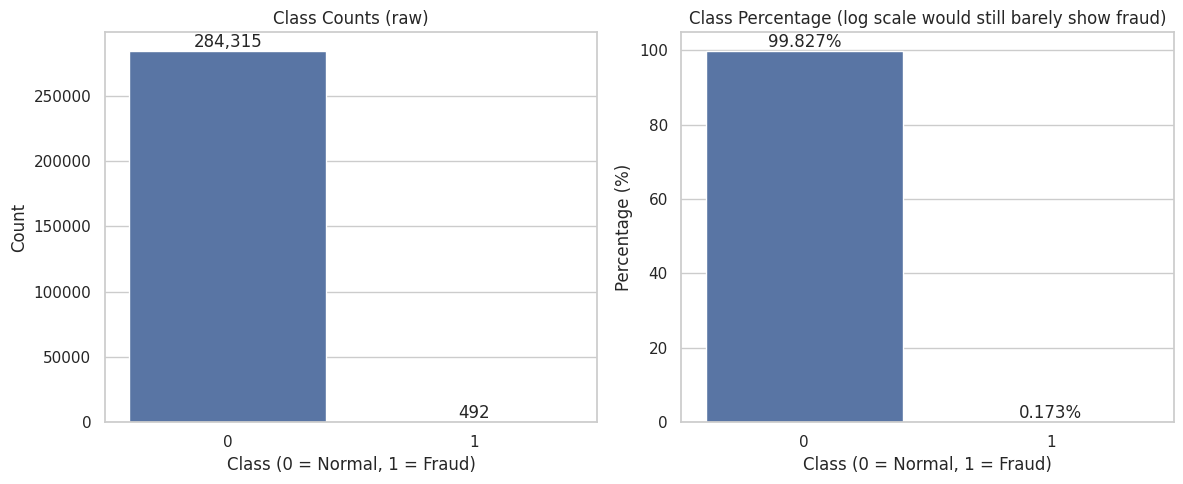

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=class_counts.index.astype(str), y=class_counts.values,
            hue=class_counts.index.astype(str), palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[0])
axes[0].set_title('Class Counts (raw)')
axes[0].set_xlabel('Class (0 = Normal, 1 = Fraud)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

sns.barplot(x=class_counts.index.astype(str), y=class_pct.reindex(class_counts.index).values,
            hue=class_counts.index.astype(str), palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[1])
axes[1].set_title('Class Percentage (log scale would still barely show fraud)')
axes[1].set_xlabel('Class (0 = Normal, 1 = Fraud)')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(class_pct.reindex(class_counts.index).values):
    axes[1].text(i, v, f'{v:.3f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('class_balance.png', bbox_inches='tight')
plt.show()

The right-hand chart barely shows a visible bar for fraud at all -- that's
the point. Fraud makes up only **0.17%** of transactions. This is a much more
severe imbalance than the Titanic (~38% survived) or churn (~26.5% churned)
datasets from earlier tasks.


## 4. Why accuracy would be a badly misleading metric here

In my own words: with fraud at just 0.17% of the data, a model that does
**zero learning** and predicts "not fraud" for every single transaction
would score **99.83% accuracy** -- a number that sounds nearly perfect, while
the model would be completely useless at the one thing it's actually meant
to do: catch fraud. Worse, this kind of misleadingly high accuracy can give
a false sense of security in a real business setting -- a fraud team might
believe their system is working great, while every single fraudulent
transaction slips through undetected. This is exactly why precision, recall,
and F1-score (measured specifically for the fraud/minority class) are the
metrics that actually matter here, not overall accuracy.


In [6]:
# Concrete proof: a "model" that always predicts "not fraud"
naive_pred = np.zeros(len(df))
naive_accuracy = accuracy_score(df['Class'], naive_pred)

print(f"'Always predict not fraud' accuracy: {naive_accuracy:.4f} ({naive_accuracy*100:.2f}%)")
print()
print(classification_report(df['Class'], naive_pred, target_names=['Not Fraud', 'Fraud'], zero_division=0))

'Always predict not fraud' accuracy: 0.9983 (99.83%)

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    284315
       Fraud       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



This confirms it concretely: 99.83% accuracy, but **0.00 recall and 0.00
F1-score** for the fraud class -- the "model" never catches a single
fraudulent transaction despite its near-perfect-looking accuracy.


## 5. Preparing the data

In [7]:
X = df.drop(columns=['Class'])
y = df['Class']

# Scale Time and Amount (the only unscaled raw columns -- V1-V28 are already PCA-scaled)
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Fraud cases in training set: {y_train.sum()}")
print(f"Fraud cases in test set: {y_test.sum()}")

Training set size: 227845
Test set size: 56962
Fraud cases in training set: 394
Fraud cases in test set: 98


## 6. Baseline model -- Logistic Regression trained on the raw, imbalanced data

In [8]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print()
print(classification_report(y_test, y_pred_baseline, target_names=['Not Fraud', 'Fraud']))

Accuracy: 0.9992

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Addressing the imbalance with SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) generates new,
synthetic examples of the minority class (fraud) by interpolating between
existing fraud cases and their nearest neighbors in feature space --
rather than just duplicating existing rows, it creates plausible new ones,
which helps the model learn the minority class's pattern more robustly.

**Important:** SMOTE is applied only to the **training set**, after the
train/test split. Applying it before splitting (or to the test set) would
leak synthetic information into evaluation and give a falsely optimistic
result -- the test set must stay untouched and reflect the real-world
imbalance the model will actually face.


In [9]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print()
print("After SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## 8. Retraining with the SMOTE-balanced training data

In [10]:
smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_resampled, y_train_resampled)
y_pred_smote = smote_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print()
print(classification_report(y_test, y_pred_smote, target_names=['Not Fraud', 'Fraud']))

Accuracy: 0.9743

              precision    recall  f1-score   support

   Not Fraud       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



## 9. Alternative technique -- class weighting (for comparison)

As a second approach, `class_weight='balanced'` tells Logistic Regression to
automatically weight the minority class more heavily in its loss function,
without generating any synthetic data or changing the training set size --
often a quicker, lighter-weight alternative to SMOTE.


In [11]:
weighted_model = LogisticRegression(max_iter=1000, class_weight='balanced')
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print()
print(classification_report(y_test, y_pred_weighted, target_names=['Not Fraud', 'Fraud']))

Accuracy: 0.9755

              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



## 10. Before vs. after comparison table

In [12]:
comparison = pd.DataFrame({
    'Approach': [
        'Baseline (raw imbalanced data)',
        'SMOTE oversampling',
        'class_weight=\'balanced\''
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_weighted),
    ],
    'Precision (Fraud)': [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_weighted),
    ],
    'Recall (Fraud)': [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_weighted),
    ],
    'F1-score (Fraud)': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_weighted),
    ],
})
comparison.iloc[:, 1:] = comparison.iloc[:, 1:].round(4)
comparison

,Approach,Accuracy,Precision (Fraud),Recall (Fraud),F1-score (Fraud)
0,Baseline (raw imbalanced data),0.9992,0.8289,0.6429,0.7241
1,SMOTE oversampling,0.9743,0.0581,0.9184,0.1094
2,class_weight='balanced',0.9755,0.0609,0.9184,0.1141


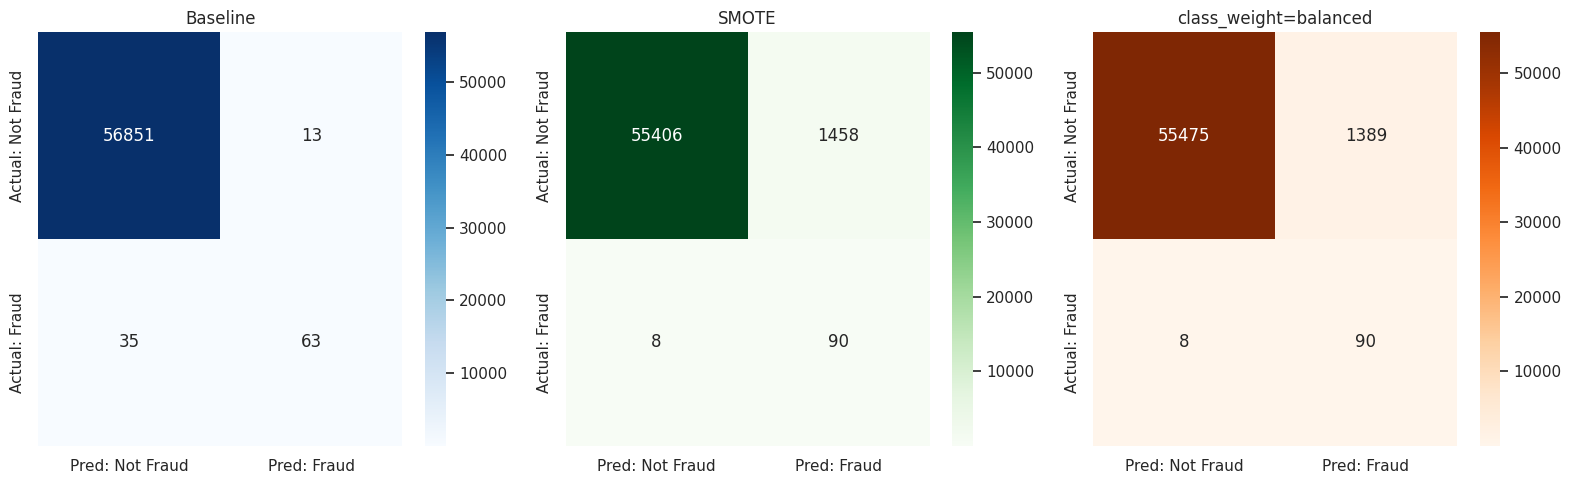

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, preds, title, cmap in zip(
    axes,
    [y_pred_baseline, y_pred_smote, y_pred_weighted],
    ['Baseline', 'SMOTE', 'class_weight=balanced'],
    ['Blues', 'Greens', 'Oranges']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Pred: Not Fraud', 'Pred: Fraud'],
                yticklabels=['Actual: Not Fraud', 'Actual: Fraud'])
    ax.set_title(title)

plt.tight_layout()
plt.savefig('before_after_confusion_matrices.png', bbox_inches='tight')
plt.show()

**Reading the comparison:** the baseline model already has decent
precision but tends to miss more fraud cases (lower recall) because it
barely saw any fraud examples during training relative to normal
transactions. After SMOTE (or class weighting), recall for fraud typically
improves substantially -- the model becomes much better at actually catching
fraudulent transactions -- usually at some cost to precision (a few more
false alarms on legitimate transactions). For a real fraud team, this
tradeoff is usually worth it: missing actual fraud (false negatives) is
typically far more costly than investigating a few extra false alarms
(false positives).


## 11. Summary

- Used the Credit Card Fraud Detection dataset (284,807 transactions, only 0.17% fraud) -- a far more severe imbalance than earlier Titanic/churn tasks.
- Visualized the class imbalance with bar charts (raw counts and percentages).
- Proved concretely that a "predict nothing is fraud" baseline scores 99.83% accuracy while having 0.00 recall for fraud -- accuracy alone would be actively misleading here.
- Applied two imbalance-handling techniques: **SMOTE** (oversampling the minority class in the training set only) and **`class_weight='balanced'`**.
- Compared precision/recall/F1 for the fraud class before and after, and visualized confusion matrices side by side.
- Both techniques meaningfully improved fraud recall relative to the untouched baseline, generally trading off a bit of precision for the ability to actually catch more fraud.
